<a href="https://colab.research.google.com/github/GustavoGarcia627/Analisis-num-rico---Famaf/blob/main/2026_Practico_2_numerico_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS NUMERICO 1  – 2026
## Trabajo de laboratorio Nº 2

In [7]:
import math
import numpy

**Ejercicio 1)** Escribir una funcion que implemente el método de bisección para hallar una raíz de $f: R \to R$ en el intervalo $[a,b]$. La funcion debe llamarse `"rbisec"`, y tener como entrada los argumentos `(fun,I,err,mit)` donde `fun ` es una funcion que dado $x$ retorna $f(x)$, `I=` $[a,b]$ es un intervalo en $\mathbb{R}$, `err` es la tolerancia deseada del error y `mit` es el número máximo de iteraciones permitidas. El algoritmo debe finalizar en la $k-$ésima iteración si $|f(x_k)|< $ `err` o si $k \ge$ `mit`. Los argumentos de salida deben ser `(hx,hf)` donde `hx=`$[x_1, \dots, x_N]$ es una lista que representa el historial de puntos medios y `hf`$=[f(x_1),\dots,f(x_N)]$ el historial de los respectivos funcionales

In [ ]:
def rbisec(fun:callable, I:list, err:float, mit:int)->tuple:
  '''
  PreCondición: Recibe como argumento: Una función, extremos del intervalo [a,b], tolerancia del error y cantidad máxima de iteraciones
  PostCondición: Devuelve una tupla con dos listas:
    hx -> Lista que representa el historial de puntos medios
    hf -> Lista que representa el historial de los respectivos funcionales
  '''
  a = I[0]
  b = I[1]
  e = b-a  #Tamaño inicial del intervalo
  u = fun(a)
  v = fun(b)
  hx = []
  hf = []

  if numpy.sign(u)==numpy.sign(v): #Verifica signos
    return False
  else:
    for k in range(mit):
      e = e/2  #Divide el intervalo en 2 partes
      c = a+e
      w = fun(c)

      hx.append(c)
      hf.append(w)

      if abs(w)<err:  #Verificación cota del error
        return (hx,hf)
      if numpy.sign(w)!= numpy.sign(u):
        #c es el nuevo b del intervalo, f(b) -> f(c)
        b = c
        v = w
      else:
        #c es el nuevo a del intervalo, f(a) -> f(c)
        a = c
        u = w

La siguiente función representa: $f(x) = x^3-2$,  la cual tiene una raíz en el intervalo $[-1,2]$

In [ ]:
def f(x:float)->float:
  '''
  Pre: Recibe un valor x flotante
  Post: Devuelve el valor de x**2-1
  '''
  return x**3-2

In [ ]:
#Probamos el método:
rbisec(f,[-1,2],10**-5,100)

([0.5,
  1.25,
  1.625,
  1.4375,
  1.34375,
  1.296875,
  1.2734375,
  1.26171875,
  1.255859375,
  1.2587890625,
  1.26025390625,
  1.259521484375,
  1.2598876953125,
  1.26007080078125,
  1.259979248046875,
  1.2599334716796875,
  1.2599105834960938,
  1.2599220275878906],
 [-1.875,
  -0.046875,
  2.291015625,
  0.970458984375,
  0.426361083984375,
  0.18119430541992188,
  0.06506109237670898,
  0.00857323408126831,
  -0.01928023248910904,
  -0.005385912023484707,
  0.0015855483943596482,
  -0.0019022087944904342,
  -0.00015883709238551091,
  0.0007132289094897715,
  0.00027716422547996444,
  5.9155646066955114e-05,
  -4.9842703243374586e-05,
  4.655976386214178e-06])

**Ejercicio 2** Utilizar la funcion bisec para:

**2a)** Encontrar la menor solución positiva de la ecuación $2x = tan(x)$ con un error menor a $10^{-15}$ en menos de 100 iteraciones. ¿Cuántas iteraciones son necesarias cuando comenzamos con el intérvalo $[0.8,1.4]$? Usar la siguiente sintaxis:

```
hx,hy = rbisec(fun_lab2ej2a, [0.8,1.4],1e-5,100)
```



In [ ]:
#definimos la función del ejercicio
def fun_lab2ej2a(x:float)->float:
  '''
  Pre: Recibe un valor x
  Post: Devuelve el resultado evaluado en tan(x)-2x
  '''
  return numpy.tan(x)-2*x

In [ ]:
#Probamos el método con la nueva función:
hx,hy= rbisec(fun_lab2ej2a,[0.8,1.4],1e-5,100)

In [ ]:
print(f"La menor solucion posible de la ecuacion es: {rbisec(fun_lab2ej2a, [0.8,1.4],1e-15,100)[0][-1]}")
#hx,hy = rbisec(fun_lab2ej2a, [0.8,1.4],1e-5,100)
#print(hx)
#print(hy)

La menor solucion posible de la ecuacion es: 1.1655611852072114


**2b)** Encontrar una aproximacion a $\sqrt{3}$ con un error menor a $10^{-5}$. Para esto considere la funcion $x \to x^2 -3$ (que debe llamarse `fun_lab2ej2b`)

In [ ]:
def fun_lab2ej2b(x:float)->float:
  '''
  Pre:  Recibe un valor x
  Post: Devuelve el resultado evaluado en x**2-3
  '''
  return x**2-3

In [ ]:
print(f"La raiz cuadrada de 3 es: {rbisec(fun_lab2ej2b,[1,4],10e-15,100)[0][-1]}")

La raiz cuadrada de 3 es: 1.7320508075688767


In [ ]:
print(math.sqrt(3))

1.7320508075688772


**2c)** Graficar conjuntamente $f$ y los pares $(x_k,f(x_k))$ para las dos funciones anteriores y con al menos dos intervalos iniciales distintos para cada una

In [ ]:
#Importamos la libreria:
import matplotlib.pyplot as plt


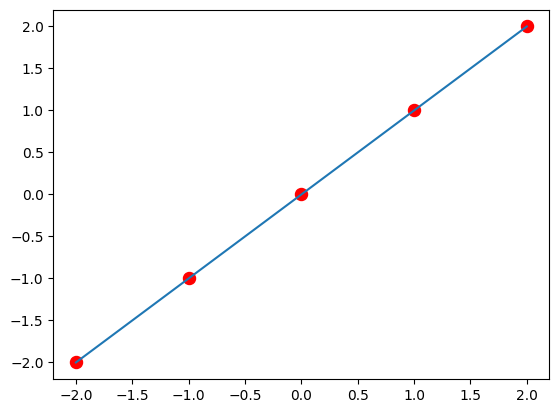

In [ ]:
#Prueba de la biblioteca matplotlib

#Puntos lineales
x_k = [-2,-1,0,1,2]
fx_k = [-2,-1,0,1,2]

plt.plot(x_k,fx_k) #gráfica los puntos unidos
plt.scatter(x_k,fx_k, s=75, color="red") # grafica los puntos de la lista
plt.show()

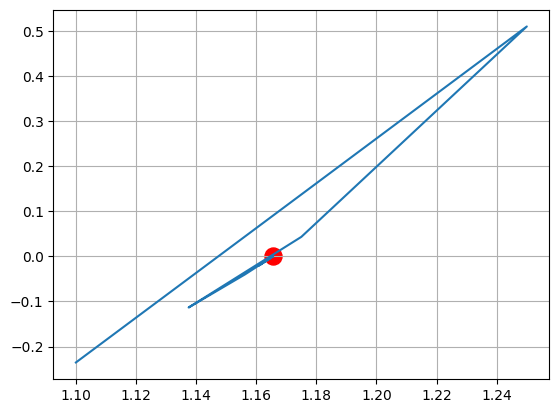

In [ ]:
hx, hf = rbisec(fun_lab2ej2a, [0.8,1.4],1e-5,100)

plt.plot(hx, hf)
plt.scatter(hx[-1], hf[-1],s=150,color="red") #El punto rojo indica la convergencia que está teniendo el método
#plt.ylabel(rbisec(fun_lab2ej2a, [0.8,1.4],1e-5,100)[1])
plt.grid()
plt.show()

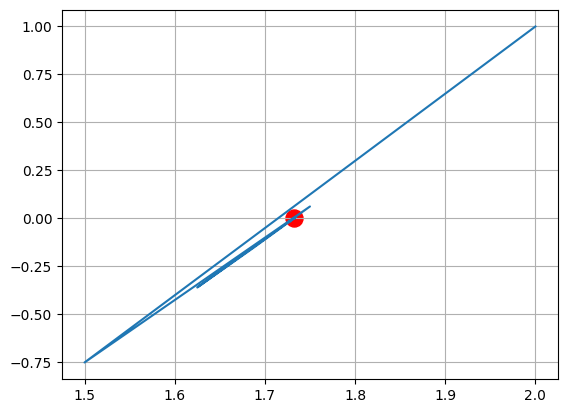

In [ ]:
hx, hf = rbisec(fun_lab2ej2b, [1,3],1e-5,100)

plt.plot(hx, hf)
plt.scatter(hx[-1], hf[-1],s=150,color="red") #El punto rojo indica la convergencia que está teniendo el método
#plt.ylabel(rbisec(fun_lab2ej2a, [0.8,1.4],1e-5,100)[1])
plt.grid()
plt.show()

In [ ]:
math.pow(2,3)

8.0

**Ejercicio 3** Escribir la funcion que implemente el método de Newton para hallar una raíz $f: \mathbb{R} \to \mathbb{R}$ partiendo de un punto inicial $x_0$. La función debe llamarse `rnewton` y tener como entrada `(fun,x0,err,mit)` donde `fun` es una funcion que dado $x$ retorna $f(x)$ y  $f'(x),$ `x0` es un punto incial en $\mathbb{R}$, `err` es la toleraciancia deseada del error y `mit` es el número máximo de iteraciones permitidas. El algoritmo debe finalizar en la $k$-ésima iteración si se cumpla alguna de las siguientes condiciones:

$\frac{|x_k - x_{k-1}|}{|x_k|}<err, \quad |f(x_k)|<err, \quad k \ge mit$

La salida debe ser `(hx,hf)` donde `hx=`$[x_1,\dots x_N]$ es una lista que representa el histórico de puntos generados y `hf`=$[f(x_1), \dots,f(x_N)]$ el historico de los respectivos valores funcionales

In [3]:
def rnewton(fun:callable, x0:float, err:float, mit:int)->tuple:
  '''
  Pre: Recibe función, punto inicial, error mínimo y máximo de iteraciones
  Pos: Devuelve una par con lista de puntos y función evaluada en los puntos
  '''
  hx =[]
  hf = []
  x1 = 0
  v = fun(x0)[0]

  if abs(v)<err: #El punto valor inicial es menor que el error
    return (hx,hf) #Devulve los puntos iniciales
  else:
    for i in range(mit):
      x1 = x0- (v/fun(x0)[1]) #Fórmula principal del método
      if abs(x1)>1e100:
        raise OverflowError("El x1 excede la capacidad numérica")
      v = fun(x1)[0]
      hx.append(x1)
      hf.append(v)
      if ( abs(x1-x0)/abs(x1) )<err or abs(v)<err : #Supera la cota de error
        return(hx,hf)
      x0 = x1
    return(hx,hf)

**Observación:** Las funciones matemáticas que ingresan al método devolveran un par donde la primer entrada es $f(x)$ y la segunda será $f'(x)$

In [ ]:
def g(x:float)->tuple:
  '''
  Pre: Recibe un x flotante
  Pos: Devuelve una tupla (fx , f'x)
  '''
  return ((x**3)-4,3*(x**2))

In [ ]:
rnewton(g,1, 10**-5,10)

([1,
  2.0,
  1.6666666666666667,
  1.5911111111111111,
  1.5874096961416333,
  1.5874010520152708],
 [-3,
  4.0,
  0.6296296296296306,
  0.028111890260631434,
  6.534621225018356e-05,
  3.5583713753339907e-10])

**Ejercicio 4)** Escribir una función que, ingresando $a>0$, retorne una aproximación de $\sqrt[3]{a}$. La aproximación debe realizarse usando el método de Newton del ejercicio anterior para resolver $x^3 -a = 0$ con un error menor a $10^{-6}$ mediante el uso de la función $x \to x^3 -a$

In [ ]:
def raiz_cubica(a:float)->float:
  '''
  Pre: Recibe una valor a
  Pos: Calcula raiz cubica de a
  '''
  def funcion_auxiliar(x):
    return(x**3-a, 3*x**2)
  return rnewton(funcion_auxiliar,1,10e-6,100)[0][-1]

In [ ]:
#Prueba
raiz_cubica(8)

2.0000000000120624

In [ ]:
#Vemos el error:
xn = raiz_cubica(8)
r = 8**(1/3)
print(abs(xn-r))

1.20623511179474e-11


**Ejercicio 5)** Escribir una función que implemente el método de iteración de punto fijo para hallar punto fijo de $\varphi : \mathbb{R} \to \mathbb{R}$, partiendo de un punto inicial $x_0$. La función debe llamarse `"ripf"`, y tener como entrada `(fun,x0,err,mit)` donde `fun` es una función que dado x retorna $\varphi(x)$, `x0`es un punto en $\mathbb{R}$, `err`es la tolerancia deseada del error y `mit`es el número máximo de iteraciones permitidas. EL algoritmo debe finalizar en la $k$-esima iteración si $|x_k - x_{k-1}|<$ `err` ó bien $k \le $ `mit`. La salida debe ser `hx`donde `hx`= $[x_1, \dots, x_N]$ es una lista del historico de puntos generados

In [ ]:
def ripf(fun,x0,err,mit)->list:
  '''
  Pre: Recibe función, punto inicial, cota derror y máximo de iteración
  Pos: Devuelve lista del historico de puntos generados
  '''
  i = 1
  hx = [x0]
  while i <= mit: #Parada por máximo de iteracioines superado
    p = fun(x0)
    if abs(p-x0)<err:
      return hx
    else:
      i+=1
      x0=p
      hx.append(x0) #Agrega a la lista el siguiente p
  return hx

In [ ]:
#Hacemos la prueba
def g(x):
  return x**2

In [ ]:
lista = ripf(g,0.01,10e-15,1000)
for i in range(len(lista)):
  print(f"x_{i}= {lista[i]}")  #los valores convergen a 0
print(g(lista[-1]) -lista[-1]) #Probamos al valor último resultado como raíz

x_0= 0.01
x_1= 0.0001
x_2= 1e-08
x_3= 1.0000000000000001e-16
-1e-16


**Ejercicio 6** Se quiere usar la fórmula de iteración $x_{n+1} = 2^{x_n-1}$ para resolver la ecuación $2x = 2^x$. Utilizar la función del ejercicio anterior para investigar si converge; y en caso afirmativo, estudiar hacia qué valores lo hace para distintas elecciones de $x_0$, tomando un número máximo de 100 iteraciones y un error menor a $10^{-5}$. Usar la siguiente sintaxis:

```
hx = ripf(fun_lab2ej6,x0,1e-5,100)
```



In [ ]:
def fun_lab2ej6(x):
  return ((2**x)/2)

In [ ]:
hx = ripf(fun_lab2ej6,1/2, 10e-5,100)
for i in hx:
  print(i)

0.5
0.7071067811865476
0.8162634597190764
0.880419777940014
0.9204554346455052
0.9463563484142552
0.9634998509235502
0.9750173869029087
0.9828324432586594
0.9881708772048512
0.9918341996519106
0.9943558867069766
0.9960954414735285
0.9972972253560505
0.9981283331329291
0.9987035005706679
0.9991017387543508
0.9993775665422959
0.9995686550596955
0.9997010591624983


In [ ]:
hx = ripf(fun_lab2ej6,3, 10e-5,100)
for i in hx:
  print(i)

OverflowError: (34, 'Numerical result out of range')

**Respuesta:** Observar que la sucesión converge al valor $x_n = 0$ cuando se le da un intérvalo correspondiente. Sin embargo si porbamos con valores como $x_0 = 3$ está se rompe en el intento, viendo que no cumple con las condiciones del teorema (La función no está "mapeando" al valor 3)

**Ejercicio 7** Se desea conocer la gráfica de una función $u$ definida implícitamente como $u(x) = y$  donde $y$ es solución de
$$y - e^{-(1-xy)^2} =0 $$
Implementar tres versiones de esta función, hallando el valor de y con los métodos de los ejercicios de bisección (`lab2ej7bisec`), Newton (`lab2ej7newton`) y punto fijo (`lab2ej7ipf`). Los valores iniciales y tolerancias usadas por los distintos métodos deben ser escogidos de manera que cualquier usuario pueda graficar $u$ en el intervalo $[0,1.5]$ sin inconvenientes.

Comenzamos con el método de bisección:

In [ ]:
def lab2ej7bisec (x):
  '''
  Pre:  Recibe un par x
  Post: Devuelve los valores:
    hx -> aproximaciones a la raíz
    hf -> Valores de f(hx)
  '''
  # Aquí x es una constante que viene de afuera
  # Definimos la función f respecto a y
  f = lambda y : y - math.exp(-(1 - x*y)**2)
  return rbisec(f,[0,1],10e-15,100)

**Observación:** Para que la funcíon propuesta tenga una raíz (Se cumpla que $f(0)\cdot f(1.5)<0$) se tiene que considerar a y como un valor $y = 0.5$ de lo contrario el algoritmo de bisección no inicia a falta de cumplir con la hipotesis

In [ ]:
tabla_valores = lab2ej7bisec(0.5)
for i in tabla_valores[0]:
  print(i)

0.5
0.75
0.625
0.5625
0.59375
0.609375
0.6171875
0.62109375
0.623046875
0.6220703125
0.62255859375
0.622314453125
0.6221923828125
0.62213134765625
0.622100830078125
0.6221160888671875
0.6221084594726562
0.6221046447753906
0.6221027374267578
0.6221017837524414
0.6221022605895996
0.6221024990081787
0.6221026182174683
0.6221025586128235
0.6221025288105011
0.6221025437116623
0.6221025362610817
0.6221025325357914
0.6221025306731462
0.6221025316044688
0.6221025311388075
0.6221025313716382
0.6221025312552229
0.6221025311970152
0.622102531226119
0.6221025312406709
0.6221025312479469
0.6221025312443089
0.6221025312424899
0.6221025312415804
0.6221025312420352
0.6221025312422626
0.6221025312423762
0.6221025312423194
0.622102531242291


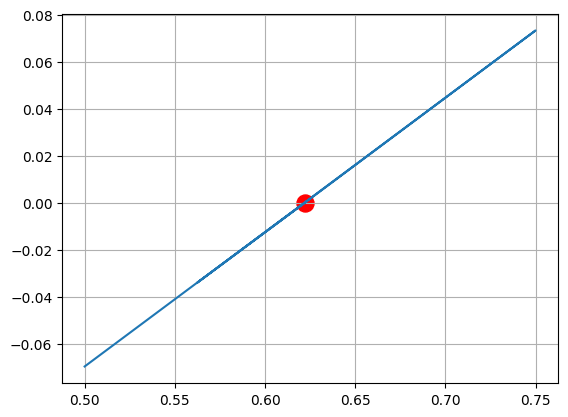

In [ ]:
#Intentamos gráficar
plt.plot(tabla_valores[0], tabla_valores[1])
plt.scatter(tabla_valores[0][-1], tabla_valores[1][-1],s=150,color="red") #Punto donde converge la raíz
plt.grid()
plt.show()

Método de newton

In [ ]:
def lab2ej7newton(x):
  '''
  Pre:  Recibe un par x
  Post: Devuelve los valores:
    hx -> aproximaciones a la raíz
    hf -> Valores de f(hx)
  '''
  # Aquí x es una constante que viene de afuera
  # Definimos la función f respecto a y
  def fun_aux ( y):
    return y - math.exp(-(1 - x*y)**2), 1 - math.exp(-(1 - x*y)**2) * 2 * x * (1 - x*y)
  return rnewton(fun_aux,x,10e-5,100)

In [ ]:
tabla_valores2 = lab2ej7newton(0.5)
for i in tabla_valores2[0]:
  print(i)

0.5
0.6218567275637116
0.62210253207225


**Observación:** Se puede ver que converge más rápido que bisección

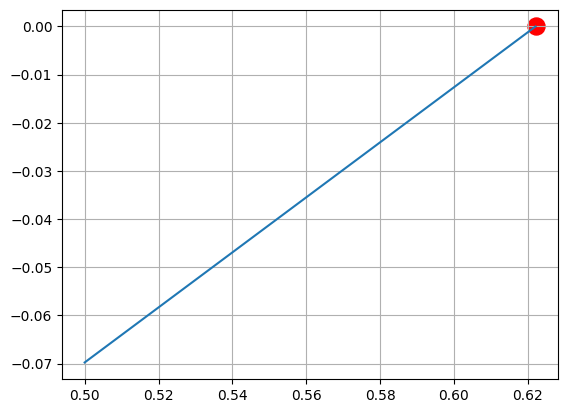

In [ ]:
#Intentamos gráficar
plt.plot(tabla_valores2[0], tabla_valores2[1])
plt.scatter(tabla_valores2[0][-1], tabla_valores2[1][-1],s=150,color="red") #Punto donde converge la raíz
plt.grid()
plt.show()

Método de punto fijo

In [ ]:
def lab2ej7ipf(x):
  '''
  Pre:  Recibe un par x
  Post: Devuelve los valores:
    hx -> aproximaciones a la raíz
    hf -> Valores de f(hx)
  '''
  # Aquí x es una constante que viene de afuera
  # Definimos la función f respecto a y
  def funcion_auxiliar(y):
    return math.exp(-(1 - x*y)**2)
  return ripf(funcion_auxiliar,0.5,10e-15,100)


In [ ]:
tabla_valores3 = lab2ej7ipf(0.5)
for i in tabla_valores3:
  print(i)


0.5
0.569782824730923
0.5996672912744245
0.6124837155451968
0.6179792736272622
0.6203351874981939
0.6213450292299629
0.6217778638478401
0.621963379023051
0.6220428909006737
0.6220769695575846
0.6220915755821145
0.6220978356809856
0.6221005187397987
0.6221016686902321
0.6221021615552783
0.622102372795641
0.622102463332575
0.6221025021364109
0.622102518767609
0.6221025258956865
0.6221025289507573
0.6221025302601508
0.6221025308213526
0.6221025310618818
0.6221025311649719
0.622102531209156
0.6221025312280932
0.6221025312362095
0.6221025312396882
0.6221025312411791
0.622102531241818
0.6221025312420919
0.6221025312422094
0.6221025312422597
0.6221025312422812


**Ejercicio 8)** Encontrar el mínimo de la función $f(x) = \frac{tanx}{x^2}$ en el intervalo $ (0,\frac{\pi}{2})$. Para ello calcular la raíz de su derivada usando el método de Newton

Calculamos la derivada de $f(x)$:
$$f'(x)= \frac{x^2 \cdot \sec^2(x) - 2x ⋅ \tan(x)}{x^4}$$
Para emplear el método de Newton necesitamos derivar nuevamente de modo que:
$$f''(x)= \frac{2\sec^2(x) \left(\tan(x) (2x \tan(x)-1)+\sec^2(x)\right)}{x^2}$$

In [5]:
def ej8f(x):
    def sec(x):
        if math.cos(x) == 0 or x == 0:
            raise ValueError("El número no es válido (división por cero o secante indefinida)")
        return 1 / math.cos(x)

    # Cálculo de la secante una sola vez para eficiencia
    s = sec(x)
    t = math.tan(x)

    # Primera parte del return (Derivada respecto a x)
    f_x = (x**2 * s**2 - 2 * x * t) / (x**4)
    f_y = (2 * s**2 * (2 * x * t - 2) + s**2) / (x**2)

    return f_x, f_y

In [26]:
# Calculamos la raíz de la derivada que equivale
# al mínimo local de la función derivada
rnewton(ej8f,1,10e-15,100)[0][-1]

0.9477471335169916

**Ejercicio 9** La generación de energía de un molino de viento depende del diámetro de la circunferencia generada por sus aspas y la velocidad del viento de la zona. Una buena estimación de la energía generada está dada por la fórumla:

$$
E = 0.01328 D^2 V^3
$$

donde $E$ es la energía generada, $D$ es el diámetro en metros y $V$ es la velocidad del viento en $m/s$.

Usar el método de Newton para determinar el diámetro del molino si se desea generar $500W$ de energía eléctrica cuando la velociadad del viento es de 24 km/h.

Sea $ a = 0.01328$ Entonces de la formula podemos despejar $D$ tal que

$$
D^2 = \frac{E}{a \cdot V^3}
$$

Al emplear el método de Newton, buscamos la raiz que le corresponda al resultado entonces:

$$
0 = D^2-\frac{E}{a \cdot V^3} \iff D_m^2 - \frac{500_W}{0.01328 \cdot 24^3_{m/s}}=0
$$

In [27]:
def funEj9Lab2(d):
  '''
  PreCondicion: Recibe un valor x real
  PosCondición: Devuelve una tupla con f(x) y f'(x)
  '''
  return (d**2-(500/(0.01328*(24**3))),2*d)

In [32]:
print(f"El valor del diametro del molino debe ser: {rnewton(funEj9Lab2,1, 10**-500,20)[0][-1]} metros cuadrados")

El valor del diametro del molino debe ser: 1.6503235690741613 metros cuadrados


# Trabajos prácticos
Este espacio es para aprovechar los métodos y usarlos de apoyo para el práctico de la materia

**Guía 3,Ejercicio 3**: Proponer una fórmula de iteración para aproximar el recíproco de la raíz cuadrada de un número positivo $r$ utilizando el Método de Newton.

Si $a$ es un número real, recordar el recíproco de este número es un $b$ tal que: $a \cdot b = 1$.

Entonces propongo una función $$f(x) = \frac{1}{\sqrt{a}}-x$$
Donde una raíz de esta función supondría ser el valor del recíproco de la raíz cuadrada de un número.

In [ ]:
def reciproco_sqrt(x0,a):
  '''
  Pre: x0-> Punto inicial, a->valor de la raíz
  Post: Devuelve el valor más próximo al reciproco de sqrt(a)
  '''
  def fun_auxiliar(x):
    return (x**2-1/a,2*x)
  lista_resultados = rnewton(fun_auxiliar,x0,10e-15,10)
  return lista_resultados

In [ ]:
#Vemos la aproximación:
print(reciproco_sqrt(1,5))
#Vemos mediante la biblioteca math.
#print(1/math.sqrt(3))

#Vemos el error absoluto
#print(abs((1/math.sqrt(3) - reciproco_sqrt(1/2,3) )))

([0.6, 0.4666666666666667, 0.44761904761904764, 0.4472137791286728, 0.4472135954999956, 0.4472135954999579], [0.15999999999999998, 0.01777777777777778, 0.0003628117913832274, 1.642425493109112e-07, 3.36952687973735e-14, -2.7755575615628914e-17])


In [ ]:
print(1/math.sqrt(5))

0.4472135954999579
